# Visualizing the History of Nobel Prize Winners

![nobel_prize.webp](imgs/nobel_prize.webp)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.



- ## Loading in required libraries:

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

- ## Exploring the data:

In [5]:
nobel = pd.read_csv('data/nobel.csv').fillna(0)
print(nobel.head())
print(nobel.columns)
print(nobel['gender'])

   prize_year    category                                           prize  \
0        1901   Chemistry               The Nobel Prize in Chemistry 1901   
1        1901  Literature              The Nobel Prize in Literature 1901   
2        1901    Medicine  The Nobel Prize in Physiology or Medicine 1901   
3        1901       Peace                      The Nobel Peace Prize 1901   
4        1901       Peace                      The Nobel Peace Prize 1901   

                                          motivation prize_share  laureate_id  \
0  "in recognition of the extraordinary services ...         1/1          160   
1  "in special recognition of his poetic composit...         1/1          569   
2  "for his work on serum therapy, especially its...         1/1          293   
3                                                  0         1/2          462   
4                                                  0         1/2          463   

  laureate_type                     full_name  bir

- ## Most awarded gender using if elif and else

In [6]:
female_nobel = nobel[nobel['gender'] == 'Female'].shape[0]
male_nobel = nobel[nobel['gender'] == 'Male'].shape[0]
if female_nobel > male_nobel:
  top_gender = 'Female'
elif male_nobel > female_nobel:
  top_gender = 'Male'
else:
  top_gender = 'Equal'
print(top_gender)

Male


- ## Create count plot to visulise data

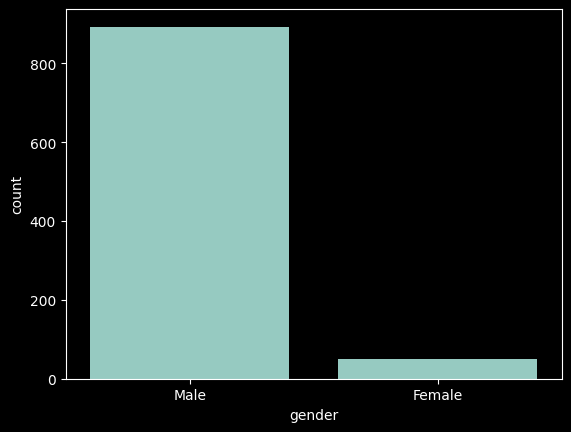

In [7]:
gender = nobel[nobel['gender'].isin(['Male','Female'])]
sns.countplot(data=gender,x='gender')
plt.show()

- ## Most awarded country

United States of America


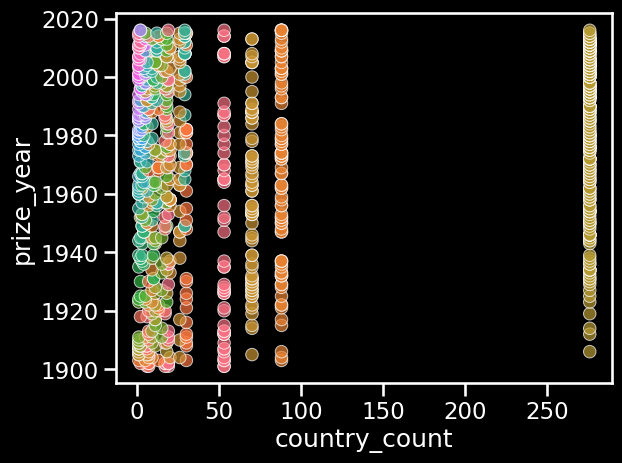

In [8]:
countries_value = nobel['birth_country'].value_counts()
nobel["country_count"] = nobel["birth_country"].map(countries_value)
sns.set_palette("PuRd")
sns.set_context('talk')
a = sns.scatterplot(data=nobel, x='country_count',y='prize_year',hue='birth_country',alpha=0.7)
a.legend_.remove()
top_country = nobel['birth_country'].value_counts().idxmax()
print(top_country)

All code (to be formatted)

   prize_year    category                                           prize  \
0        1901   Chemistry               The Nobel Prize in Chemistry 1901   
1        1901  Literature              The Nobel Prize in Literature 1901   
2        1901    Medicine  The Nobel Prize in Physiology or Medicine 1901   
3        1901       Peace                      The Nobel Peace Prize 1901   
4        1901       Peace                      The Nobel Peace Prize 1901   

                                          motivation prize_share  laureate_id  \
0  "in recognition of the extraordinary services ...         1/1          160   
1  "in special recognition of his poetic composit...         1/1          569   
2  "for his work on serum therapy, especially its...         1/1          293   
3                                                  0         1/2          462   
4                                                  0         1/2          463   

  laureate_type                     full_name  bir

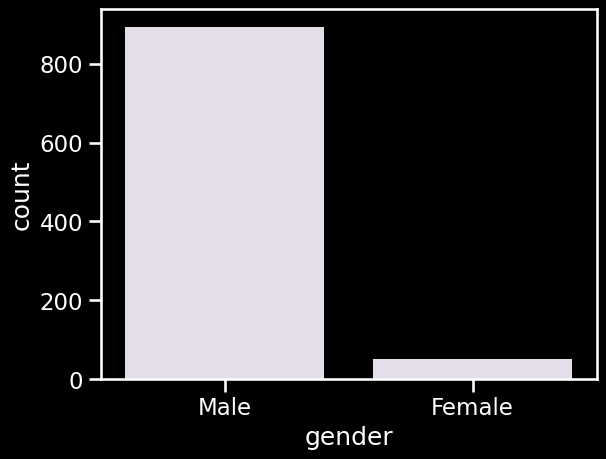

Male
United States of America
2000
{np.int64(2010): 'Peace'}
Marie Curie, née Sklodowska
Physics
['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Jack W. Szostak', 'Marie Curie, née Sklodowska', 'Paul Ehrlich', 'Carl Bosch', 'Friedrich Bergius', 'William Parry Murphy', 'Petrus (Peter) Josephus Wilhelmus Debye', 'Richard Kuhn', 'Adolf Friedrich Johann Butenandt', 'Antonio Caetano de Abreu Freire Egas Moniz', 'Hideki Yukawa', 'Hermann Staudinger', 'Fritz Albert Lipmann', 'Linus Carl Pauling', 'John Franklin Enders', 'Office of the United Nations High Commissioner for Refugees (UNHCR)', 'Walther Bothe', 'Werner Forssmann', 'John Bardeen', 'Frederick Sanger', 'Igor Yevgenyevich Tamm', 'Il´ja Mikhailovich Frank', 'Rudolf Ludwig Mössbauer', 'Christian de Duve', 'Ilya Prigogine', 'Abdus Salam', 'Jean-Marie Lehn', 'Johann Deisenhofer', 'Georges Charpak', 'Claude Cohen-Tannoudji', 'Günter Blobel', 'Kurt Wüthrich', 'Roderick MacKinnon', 'Finn E. Kydland', 'E

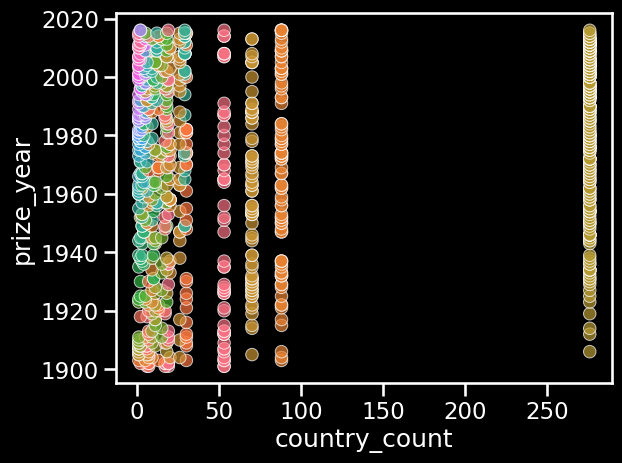

In [9]:
# Loading in required libraries:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Exploring the data:
nobel = pd.read_csv('data/nobel.csv').fillna(0)
print(nobel.head())
print(nobel.columns)
print(nobel['gender'])

# Most awarded gender using if elif and else
female_nobel = nobel[nobel['gender'] == 'Female'].shape[0]
male_nobel = nobel[nobel['gender'] == 'Male'].shape[0]
# Create count plot to visulise data
gender = nobel[nobel['gender'].isin(['Male','Female'])]
sns.countplot(data=gender,x='gender')
plt.show()

if female_nobel > male_nobel:
  top_gender = 'Female'
elif male_nobel > female_nobel:
  top_gender = 'Male'
else:
  top_gender = 'Equal'
print(top_gender)

# Most awarded country
countries_value = nobel['birth_country'].value_counts()
nobel["country_count"] = nobel["birth_country"].map(countries_value)
sns.set_palette("PuRd")
sns.set_context('talk')
a = sns.scatterplot(data=nobel, x='country_count',y='prize_year',hue='birth_country',alpha=0.7)
a.legend_.remove()
top_country = nobel['birth_country'].value_counts().idxmax()
print(top_country)

# Decade with highest number of US born nobel prize laurettes:

nobel['decade'] = (nobel['prize_year'] // 10) * 10

total_per_decade = nobel.groupby("decade").size()
usa_per_decade = nobel.loc[nobel["birth_country"] == "United States of America"].groupby("decade").size()
usa_ratio = (usa_per_decade / total_per_decade).fillna(0)
max_decade_usa = usa_ratio.idxmax()
print(max_decade_usa)

# Which decade and Nobel Prize category combination had the highest proportion of female laureates? df.loc[rows,columns]

nobel["is_female"] = nobel["gender"].eq("Female")
female_ratio = nobel.groupby(["decade", "category"])["is_female"].mean()
max_combo = female_ratio.idxmax()
max_female_decade, max_female_category = max_combo
max_female_dict = {max_female_decade: max_female_category}
print(max_female_dict)

# Who was the first woman to receive a Nobel Prize, and in what category?

first_woman_idx = nobel.loc[nobel['gender'] == 'Female','prize_year'].idxmin()
first_woman_name = nobel.loc[first_woman_idx, 'full_name']
print(first_woman_name)

first_woman_category = nobel.loc[first_woman_idx, 'category']
print(first_woman_category)

# Which individuals or organizations have won more than one Nobel Prize throughout the years?

counts = nobel["full_name"].value_counts()
repeat_list = counts[counts >= 2].index.tolist()
print(repeat_list)